<a href="https://colab.research.google.com/github/Mxgisha/chaotic-dynamical-systems-Research-tufts/blob/main/Lorenze_63.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# install stuff
#!pip uninstall -y jax jaxlib jax-cuda12-plugin
!pip install -U "jax[cuda12]"
#!pip install "jax==0.7.2" "jaxlib==0.7.2" -f https://storage.googleapis.com/jax-releases/jax_cuda_releases.html --no-deps --force-reinstall
!pip install diffrax optax equinox


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 81.6 MB/s eta 0:00:00
  Attempting uninstall: jax-cuda12-pjrt
    Found existing installation: jax-cuda12-pjrt 0.7.2
    Uninstalling jax-cuda12-pjrt-0.7.2:
      Successfully uninstalled jax-cuda12-pjrt-0.7.2
  Attempting uninstall: jax-cuda12-plugin
    Found existing installation: jax-cuda12-plugin 0.7.2
    Uninstalling jax-cuda12-plugin-0.7.2:
      Successfully uninstalled jax-cuda12-plugin-0.7.2
  Attempting uninstall: jaxlib
    Found existing installation: jaxlib 0.7.2
    Uninstalling jaxlib-0.7.2:
      Successfully uninstalled jaxlib-0.7.2
  Attempting uninstall: jax
    Found existing installation: jax 0.7.2
    Uninstalling jax-0.7.2:
      Successfully uninstalled jax-0.7.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 199.7/199.7 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.6/77.6 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 101.7/101.7 kB 12.4 MB/s eta 0:00:00


In [1]:
import jax
import jax.numpy as jnp
import jax.random as jrandom
from diffrax import ODETerm, diffeqsolve, Tsit5, SaveAt
import matplotlib.pyplot as plt
from pathlib import Path
import equinox as eqx
import optax
import jax.nn as jnn
import jax.random as jrandom

In [2]:
from jax import config
config.update("jax_enable_x64", True)

In [3]:
# parameters and vars
init_state = jnp.array([1., 1., 1.], dtype=jnp.float64)
parms = [10 ,28 ,8/3]
dt = 0.01
burn_in_steps = 1000
record_steps = 5000
total_steps = burn_in_steps + record_steps
delta = 1e-6 #used in lyapanove expon
master_key = jrandom.PRNGKey(67)

In [4]:
# lorenze 63 ground truth
def lorenze_63(t ,state ,args = parms):
  x, y, z = state
  sigma, row, beta = args

  dx = sigma*(y - x) # intesty of convection
  dy = x*(row - z) - y # temperature diffrence
  dz = x*y - beta*z # distortion of the temperature profile

  return jnp.array([dx, dy, dz])

In [5]:
# solver
term = ODETerm(lorenze_63)
solver = Tsit5()

In [6]:
# stepper
def stepper(carry, x):
  solution = diffeqsolve(term, solver, t0 = 0, t1 = dt, dt0 = dt, y0 = carry, args = parms)
  next_carry = solution.ys[-1]
  return next_carry ,next_carry

In [7]:
 # scan
init_state_float64 = jnp.asarray(init_state, dtype=jnp.float64)
final_traj_1, historical_traj_1 = jax.lax.scan(stepper, init_state_float64, jnp.arange(total_steps))

In [8]:
# small permutation
init_state_2 = jnp.array([1.1,1.,1.], dtype=jnp.float64)
final_traj_2, historical_traj_2 = jax.lax.scan(stepper, init_state_2, jnp.arange(total_steps))

In [9]:
# euclidean distance between traj
difference = historical_traj_1 - historical_traj_2
distances = jnp.linalg.norm(difference, axis=1)
log_distances = jnp.log(distances)

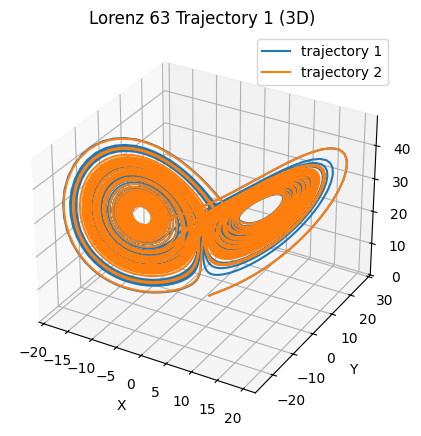

In [10]:
# print out the graphs of 1 and 2
fig = plt.figure(figsize=(10, 5))
axis = fig.add_subplot(111, projection='3d')
axis.plot(historical_traj_1[:, 0], historical_traj_1[:, 1], historical_traj_1[:, 2], label='trajectory 1')
axis.plot(historical_traj_2[:, 0], historical_traj_2[:, 1], historical_traj_2[:, 2], label='trajectory 2')
axis.set_xlabel('X')
axis.set_ylabel('Y')
axis.set_zlabel('Z')
axis.set_title('Lorenz 63 Trajectory 1 (3D)')
axis.legend()

plt.show()

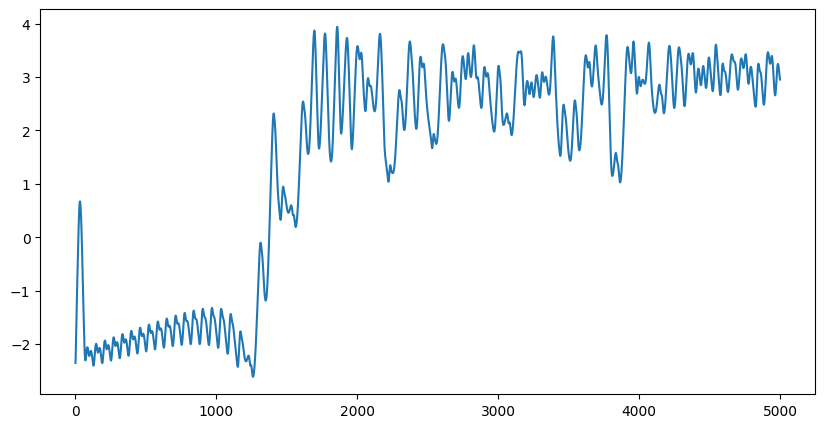

In [ ]:
# euclidian distance graphs
fig = plt.figure(figsize=(10, 5))
axis = fig.add_subplot(111)
axis.plot(log_distances)

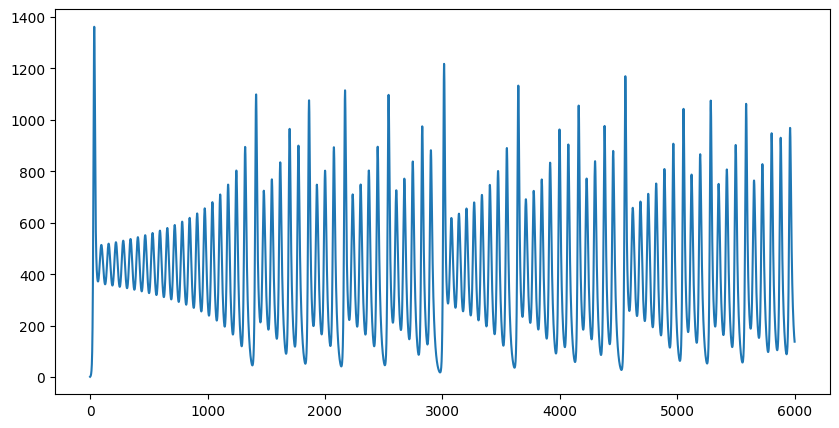

In [ ]:
# plotting energy in the physical system
# E = 1/2 (x^2 + y^2 + z^2)
def energy_func(trajectory):
  return 0.5 * jnp.sum(trajectory**2, axis=1)
energy_traj = energy_func(historical_traj_1)
fig = plt.figure(figsize=(10, 5))
axis = fig.add_subplot(111)
axis.plot(energy_traj)

In [9]:
# lyaponove exponent stepper
def lyaponove_stepper(carry, _):
    state_A, state_B = carry

    sol_A = diffeqsolve(term, solver, t0 = 0, t1 = dt, dt0 = dt, y0 = state_A, args = parms)

    sol_B = diffeqsolve(term, solver, t0 = 0, t1 = dt, dt0 = dt, y0 = state_B, args = parms)

    next_state_A = sol_A.ys[0]
    next_state_B = sol_B.ys[0]

    current_distance = jnp.linalg.norm(next_state_B - next_state_A)

    growth_factor = current_distance / delta

    direction_vector = (next_state_B - next_state_A) / current_distance
    adjusted_state_B = next_state_A + (direction_vector * delta)

    next_carry = (next_state_A, adjusted_state_B)

    return next_carry, (next_state_A, growth_factor)

In [10]:
# lyapanove expon
## initial conditions
lyap_steps = 100000
direction = jnp.array([1.0, 0.0, 0.0])
displacement = direction * delta
state_A_init = jnp.array([1.0, 1.0, 1.0])
state_B_init = state_A_init + displacement
initial_carry = (state_A_init, state_B_init)

_ , historical_growth = jax.lax.scan(lyaponove_stepper, initial_carry, jnp.arange(lyap_steps))

log_growths = jnp.log(historical_growth[1])
total_log_growth = jnp.sum(log_growths)
total_time = lyap_steps * dt

lyapunov_exponent = total_log_growth / total_time
print(lyapunov_exponent)

0.9071433975481081


In [11]:
# creating the trsting and training data set
init_states = jrandom.uniform(master_key, shape=(9, 3), minval=-15.0, maxval=15.0)
init_states = init_states.at[:, 2].add(25.0)
def generate_singel_training_traj(y0):
  save_ts_gen = jnp.arange(0.0, total_steps * dt, dt)
  sol = diffeqsolve(term, solver, t0 = 0, t1 = total_steps * dt, dt0 = dt, y0 = y0, args = parms, saveat=SaveAt(ts=save_ts_gen), max_steps=total_steps * 10)
  full_path = sol.ys.reshape(total_steps, 3)
  burnt_in_path = full_path[burn_in_steps:]
  return burnt_in_path
training_testing_trajs = jax.vmap(generate_singel_training_traj)(init_states)

In [12]:
# creating training batches
def training_dataset(trajectory, horizon, stride=1):
    window_length = horizon + 1

    # total_steps is from global scope, already defined in cell dTqSa_v1UCGf
    max_start_idx = total_steps - window_length
    start_indices = jnp.arange(start=0, stop=max_start_idx, step=stride)

    def extract_single_window(start_idx):
        single_slice = jax.lax.dynamic_slice(trajectory, (start_idx, 0), (window_length, 3))
        return single_slice

    all_windows = jax.vmap(extract_single_window)(start_indices)

    X_data = all_windows[:, 0, :].astype(jnp.float64)
    Y_data = all_windows[:, 1:, :].astype(jnp.float64)

    return X_data, Y_data

In [39]:
# setting up training data
training_trajs = training_testing_trajs[:6]
testing_trajs = training_testing_trajs[6:]
testing_initial_states = testing_trajs[:, 0, :]

# Define the prediction horizon for the emulator
# This means the emulator will be trained to predict PRED_HORIZON steps ahead.
PRED_HORIZON = 10 # You can adjust this value as needed

all_x_data = []
all_y_data = []

# Generate training data for each trajectory using the training_dataset function
for traj in training_trajs:
    x_d, y_d = training_dataset(traj, horizon=PRED_HORIZON)
    all_x_data.append(x_d)
    all_y_data.append(y_d)

x_train = jnp.concatenate(all_x_data, axis=0)
y_train = jnp.concatenate(all_y_data, axis=0)

# Verify shapes after concatenation
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")

x_train shape: (35934, 3)
y_train shape: (35934, 10, 3)


In [40]:
# input noise
master_key, noise_key = jrandom.split(master_key)
noise_scale = 0.05

input_noise = jrandom.normal(noise_key, shape=x_train.shape) * noise_scale
x_train = x_train + input_noise

print(f"x_train shape (Noisy): {x_train.shape}")
print(f"y_train shape (Clean): {y_train.shape}")

x_train shape (Noisy): (35934, 3)
y_train shape (Clean): (35934, 10, 3)


In [15]:
# setting up model
modle_key = jrandom.PRNGKey(67)
my_activation_fn = jnn.silu
new_63_model = eqx.nn.MLP(
    in_size=3,
    out_size=3,
    width_size=128,
    depth=3,
    activation=my_activation_fn,
    key=modle_key,
)

In [16]:
# rollout func
def prediction_func(model, init_state, horizontal_lenght):
    def scan_stepper(carry, _):
        current_state = carry
        next_state = model(current_state)
        return next_state, next_state
    _, prediction_seq = jax.lax.scan(scan_stepper, init_state, jnp.arange(horizontal_lenght))
    return prediction_seq

# loss and training stepper
def loss_func(model, x_single, y_trajectory):
    # x_single is (state_dim), y_trajectory is (horizon, state_dim)
    horizon = y_trajectory.shape[0]
    prediction_trajectory = prediction_func(model, x_single, horizon)
    loss = jnp.mean((prediction_trajectory - y_trajectory)**2)
    return loss

def batch_step_loss_func(model, x_batch, y_batch):
    # x_batch is (batch_size, state_dim), y_batch is (batch_size, horizon, state_dim)
    loss_sample = jax.vmap(loss_func, in_axes=(None, 0, 0))(model, x_batch, y_batch)
    return jnp.mean(loss_sample)

@eqx.filter_jit
def model_stepper(model, opt_state, optimizer, x_batch, y_batch):
    loss, grads = eqx.filter_value_and_grad(batch_step_loss_func)(model, x_batch, y_batch)
    updates, new_opt_state = optimizer.update(grads, opt_state)
    new_model = eqx.apply_updates(model, updates)
    return new_model, new_opt_state, loss

In [41]:
# optimizer setup
optimizer = optax.adam(1e-3)
model = new_63_model
opt_state = optimizer.init(eqx.filter(model, eqx.is_array))

epochs = 50
batch_size = 256
num_samples = x_train.shape[0]

for epoch in range(epochs):
    # Split the key for permutation for each epoch to ensure reproducibility
    master_key, subkey = jrandom.split(master_key)
    permutation = jrandom.permutation(subkey, num_samples) # Use subkey for permutation

    epoch_losses = []

    # Calculate number of batches (ceil division)
    num_batches = (num_samples + batch_size - 1) // batch_size

    for i in range(num_batches):
        batch_start = i * batch_size
        batch_end = min((i + 1) * batch_size, num_samples)

        # Select indices for the current batch from the permuted indices
        batch_indices = permutation[batch_start:batch_end]

        # Create batches using the selected indices
        x_batch_current = x_train[batch_indices]
        y_batch_current = y_train[batch_indices]

        # Only proceed if the batch is not empty
        if len(x_batch_current) > 0:
            model, opt_state, loss = model_stepper(model, opt_state, optimizer, x_batch_current, y_batch_current)
            epoch_losses.append(loss)

    # Correct the print condition: last epoch should be `epochs - 1`
    if epoch % 10 == 0 or epoch == epochs - 1:
        # Check if epoch_losses is not empty before calculating mean
        if epoch_losses:
            avg_loss = jnp.mean(jnp.array(epoch_losses))
            # Print current loss (from the last processed batch) and average loss for the epoch
            print(f"Epoch {epoch}, Last Batch Loss: {loss:.4f}, Average Epoch Loss: {avg_loss:.4f}")
        else:
            print(f"Epoch {epoch}, No batches processed (num_samples={num_samples}, batch_size={batch_size})")

Epoch 0, Last Batch Loss: 3.5539, Average Epoch Loss: 45.3176
Epoch 10, Last Batch Loss: 0.0581, Average Epoch Loss: 0.0858
Epoch 20, Last Batch Loss: 0.0382, Average Epoch Loss: 0.0323
Epoch 30, Last Batch Loss: 0.0504, Average Epoch Loss: 0.0618
Epoch 40, Last Batch Loss: 0.0288, Average Epoch Loss: 0.3584
Epoch 49, Last Batch Loss: 0.0425, Average Epoch Loss: 0.1338


In [20]:
def save_and_render_trajectory_plots(model, test_init_conditions, test_trajs, steps_per_traj, filename="trajectory_comparison.png", folder="plots"):
    dir_path = Path(folder)
    dir_path.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=(12, 18))

    for i in range(3):
        ic = test_init_conditions[i]
        true_path = test_trajs[i]
        emu_path = prediction_func(model, ic, steps_per_traj)

        ax = fig.add_subplot(3, 1, i + 1, projection='3d')
        ax.plot(true_path[:, 0], true_path[:, 1], true_path[:, 2], color='black', alpha=0.5, label='True Physics')
        ax.plot(emu_path[:, 0], emu_path[:, 1], emu_path[:, 2], color='crimson', alpha=0.8, linestyle='--', label='Emulator')
        ax.scatter(ic[0], ic[1], ic[2], color='gold', s=50, edgecolors='black')

        ax.set_title(f"Test Trajectory {i+1} Evaluation", fontsize=14)
        ax.legend(loc='upper right')
        ax.view_init(elev=20, azim=45)

    plt.tight_layout()

    output_path = dir_path / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f" High-resolution plot saved to: {output_path}")

    plt.show()
    plt.close(fig)

 High-resolution plot saved to: plots/trajectory_comparison_dt:0.01_total_steps:6000_noise:0.05.png


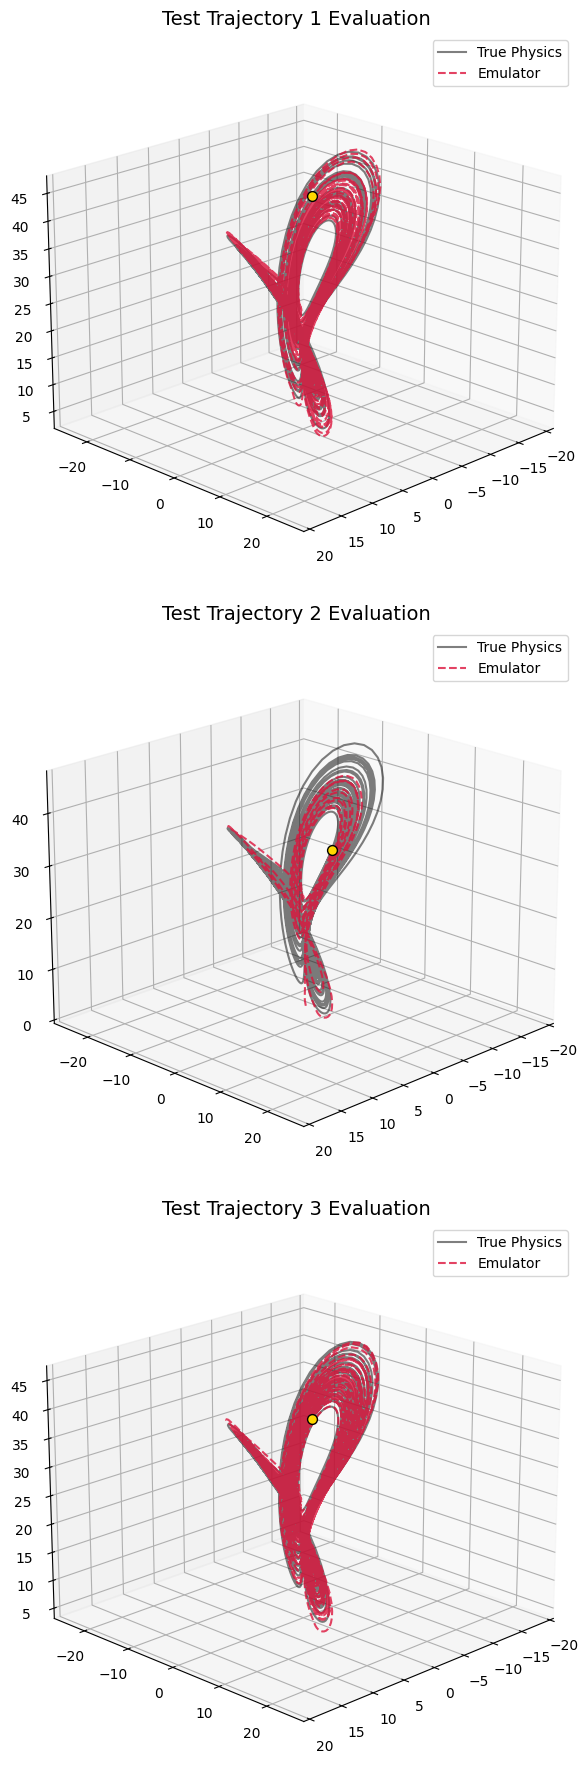

In [42]:
save_and_render_trajectory_plots(model, testing_initial_states, testing_trajs, total_steps,
                                 filename=f"trajectory_comparison_dt:{dt}_total_steps:{total_steps}_noise:{noise_scale}.png",
                                 folder="plots")

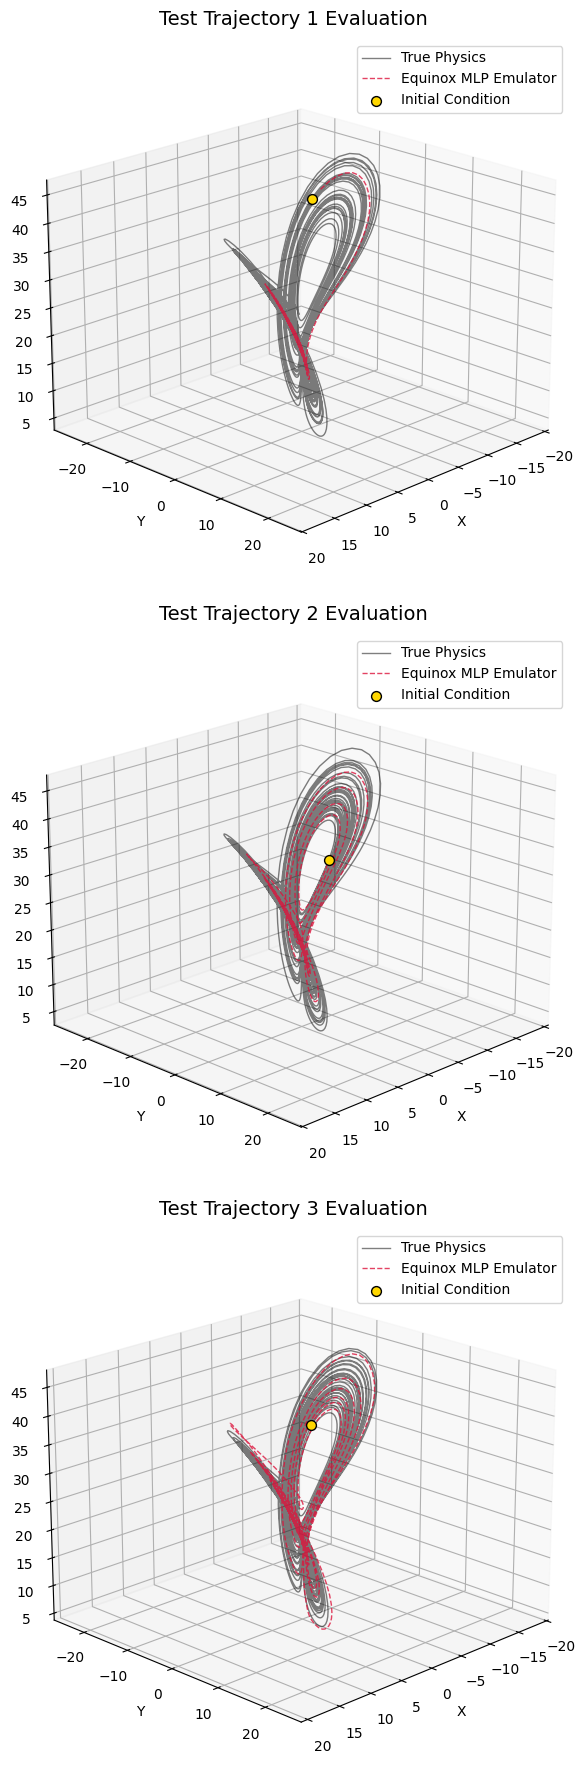

In [35]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Setup a figure with 3 subplots arranged vertically
fig = plt.figure(figsize=(12, 18))

for i in range(3):
    ic = testing_initial_states[i]
    true_path = testing_trajs[i]

    # Generate the emulator's full trajectory reconstruction from the initial condition
    emu_path = prediction_func(model, ic, total_steps)

    # Create a 3D subplot for the current trajectory pair
    ax = fig.add_subplot(3, 1, i + 1, projection='3d')

    # 1. Plot the Ground Truth Physics Trajectory
    ax.plot(
        true_path[:, 0], true_path[:, 1], true_path[:, 2],
        color='black', alpha=0.5, lw=1.0, label='True Physics'
    )

    # 2. Plot the Neural Network Emulator's Path
    ax.plot(
        emu_path[:, 0], emu_path[:, 1], emu_path[:, 2],
        color='crimson', alpha=0.8, lw=1.0, linestyle='--', label='Equinox MLP Emulator'
    )

    # 3. Mark the shared Initial Condition point
    ax.scatter(
        ic[0], ic[1], ic[2],
        color='gold', s=50, edgecolors='black', zorder=10, label='Initial Condition'
    )

    # Aesthetics and labels
    ax.set_title(f"Test Trajectory {i+1} Evaluation", fontsize=14, pad=10)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    ax.legend(loc='upper right', fontsize=10)

    # Adjust the camera viewing angle so both lobes are clearly visible
    ax.view_init(elev=20, azim=45)

plt.tight_layout()
plt.show()

In [19]:

def save_model(model, filename="lorenz_mlp.eqx", folder="saved_models"):
    dir_path = Path(folder)
    dir_path.mkdir(parents=True, exist_ok=True)

    file_path = dir_path / filename
    eqx.tree_serialise_leaves(file_path, model)
    print(f" Saved model to: {file_path}")

def load_model(model_skeleton, filename="lorenz_mlp.eqx", folder="saved_models"):
    file_path = Path(folder) / filename

    if not file_path.exists():
        raise FileNotFoundError(f"No saved checkpoint at {file_path}")

    loaded_model = eqx.tree_deserialise_leaves(file_path, model_skeleton)
    print(f" Loaded model from: {file_path}")
    return loaded_model

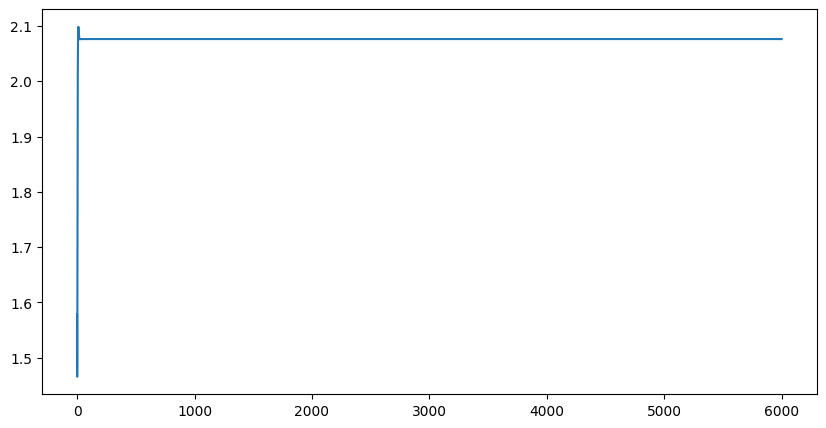

In [ ]:
# plotting energy in the emulator
emu_path = prediction_func(model, jnp.array([1.1, 1.1, 1.1]), total_steps)
energy_traj_emu = energy_func(emu_path)
fig = plt.figure(figsize=(10, 5))
axis = fig.add_subplot(111)
axis.plot(energy_traj_emu)

In [21]:
# fractal dimentions
def calculate_fractal_dimension(trajectory, r_min=0.1, r_max=10.0, num_r=20):
    N = trajectory.shape[0]
    def dist_to_all(point):
        return jnp.linalg.norm(trajectory - point, axis=-1)

    distance_matrix = jax.vmap(dist_to_all)(trajectory)

    radii = jnp.logspace(jnp.log10(r_min), jnp.log10(r_max), num=num_r)

    def compute_c_r(r):
        closer_pairs = jnp.sum(distance_matrix < r) - N
        return closer_pairs / (N * (N - 1))

    C_r = jax.vmap(compute_c_r)(radii)

    safe_mask = (C_r > 1e-8) & (radii > 0)
    log_r = jnp.log(radii[safe_mask])
    log_C = jnp.log(C_r[safe_mask])

    log_r_mean = jnp.mean(log_r)
    log_C_mean = jnp.mean(log_C)

    numerator = jnp.sum((log_r - log_r_mean) * (log_C - log_C_mean))
    denominator = jnp.sum((log_r - log_r_mean) ** 2)

    fractal_dimension = numerator / (denominator + 1e-15)

    return fractal_dimension, radii, C_r

In [31]:
# finding maxima
def find_maxima_in_z(traj):
    z_trj_left = traj[:-2, 2]
    z_trj_center = traj[1:-1, 2]
    z_trj_right = traj[2:, 2]

    is_maximum = (z_trj_center > z_trj_left) & (z_trj_center > z_trj_right)

    maximal_values = z_trj_center[is_maximum]
    return maximal_values

In [51]:
def save_and_render_unified_dashboard(
    params_dict,
    test_init_conditions, test_trajs, steps_per_traj, dt,
    radii_gt, C_r_gt, d2_gt,
    radii_emu, C_r_emu, d2_emu,
    true_path_long, emu_path_long,
    filename="experiment_dashboard.png", folder="plots"
):
    dir_path = Path(folder)
    dir_path.mkdir(parents=True, exist_ok=True)

    fig = plt.figure(figsize=(16, 22))
    gs = fig.add_gridspec(3, 3, height_ratios=[0.15, 0.45, 0.40])

    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')

    table_data = [[str(k), str(v)] for k, v in params_dict.items()]

    param_table = ax_table.table(
        cellText=table_data,
        colLabels=["Pipeline Hyperparameter", "Configured Runtime Value"],
        loc='center',
        cellLoc='left'
    )
    param_table.auto_set_font_size(False)
    param_table.set_fontsize(11)
    param_table.scale(1.0, 1.4)
    ax_table.set_title("Lorenz '63 SciML Emulator Configuration Matrix", fontsize=14, weight='bold', pad=10)

    for i in range(3):
        ax_3d = fig.add_subplot(gs[1, i], projection='3d')
        ic = test_init_conditions[i]
        true_path = test_trajs[i]

        emu_path = prediction_func(model, ic, steps_per_traj)

        ax_3d.plot(true_path[:, 0], true_path[:, 1], true_path[:, 2], color='black', alpha=0.4, lw=1.2, label='True Physics')
        ax_3d.plot(emu_path[:, 0], emu_path[:, 1], emu_path[:, 2], color='crimson', alpha=0.8, lw=1.2, linestyle='--', label='MLP Emulator')
        ax_3d.scatter(ic[0], ic[1], ic[2], color='gold', s=40, edgecolors='black', zorder=10)

        ax_3d.set_title(f"Validation Trajectory Horizon {i+1}", fontsize=11, weight='bold')
        ax_3d.set_xlabel("X")
        ax_3d.set_ylabel("Y")
        ax_3d.set_zlabel("Z")
        ax_3d.view_init(elev=20, azim=45)
        if i == 2:
            ax_3d.legend(loc='upper right', fontsize=9)

    ax_fractal = fig.add_subplot(gs[2, 0:1])
    ax_fractal.loglog(radii_gt, C_r_gt, '-o', color='black', alpha=0.5, label=f'True System ($D_2$ = {d2_gt:.3f})')
    ax_fractal.loglog(radii_emu, C_r_emu, '--x', color='crimson', alpha=0.8, label=f'MLP Emulator ($D_2$ = {d2_emu:.3f})')
    ax_fractal.set_title("Overlaid Correlation Scaling ($D_2$)", fontsize=12, weight='bold')
    ax_fractal.set_xlabel("Neighborhood Radius ($r$)")
    ax_fractal.set_ylabel("Correlation Vector Sum $C(r)$")
    ax_fractal.grid(True, which="both", alpha=0.3, ls="--")
    ax_fractal.legend(loc="upper left")

    ax_z = fig.add_subplot(gs[2, 1:3])

    maximal_values_gt = find_maxima_in_z(true_path_long[burn_in_steps:])
    maximal_values_emu = find_maxima_in_z(emu_path_long)
    ax_z.scatter(maximal_values_gt[:-1], maximal_values_gt[1:], color='black')
    ax_z.scatter(maximal_values_emu[:-1], maximal_values_emu[1:], color='red')
    #ax_z.xlabel("Previous local maximum in z")
    #ax_z.ylabel("Next local maximum in z")
    ax_z.grid()

    #ax_z.plot(time_axis, true_path_long[:, 2], color='black', alpha=0.4, label='True Physics $Z(t)$')
    #ax_z.plot(time_axis, emu_path_long[:, 2], color='crimson', alpha=0.7, linestyle='--', label='Emulator $Z(t)$')

    #max_gt_z = jnp.max(true_path_long[:, 2])
    #max_emu_z = jnp.max(emu_path_long[:, 2])

    #ax_z.axhline(max_gt_z, color='black', alpha=0.5, linestyle=':', label=f'True Ceiling Max: {max_gt_z:.2f}')
    #ax_z.axhline(max_emu_z, color='crimson', alpha=0.6, linestyle=':', label=f'Emu Ceiling Max: {max_emu_z:.2f}')

    ax_z.set_title("Overlaid Trajectory $Z$-Axis Phase Realization", fontsize=12, weight='bold')
    ax_z.set_xlabel("Physical Time Integration Units (s)")
    ax_z.set_ylabel("$Z$ Amplitude Vector")
    ax_z.grid(True, alpha=0.3, ls="--")
    ax_z.legend(loc="lower left", fontsize=9)

    plt.tight_layout()

    output_path = dir_path / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"\n[Dashboard Complete] High-resolution grid matrix exported safely to: {output_path}")

    plt.show()
    plt.close(fig)

/tmp/ipykernel_5300/2484653190.py:82: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_z.legend(loc="lower left", fontsize=9)



[Dashboard Complete] High-resolution grid matrix exported safely to: plots/lorenz_experiment_dashboard_v1.png


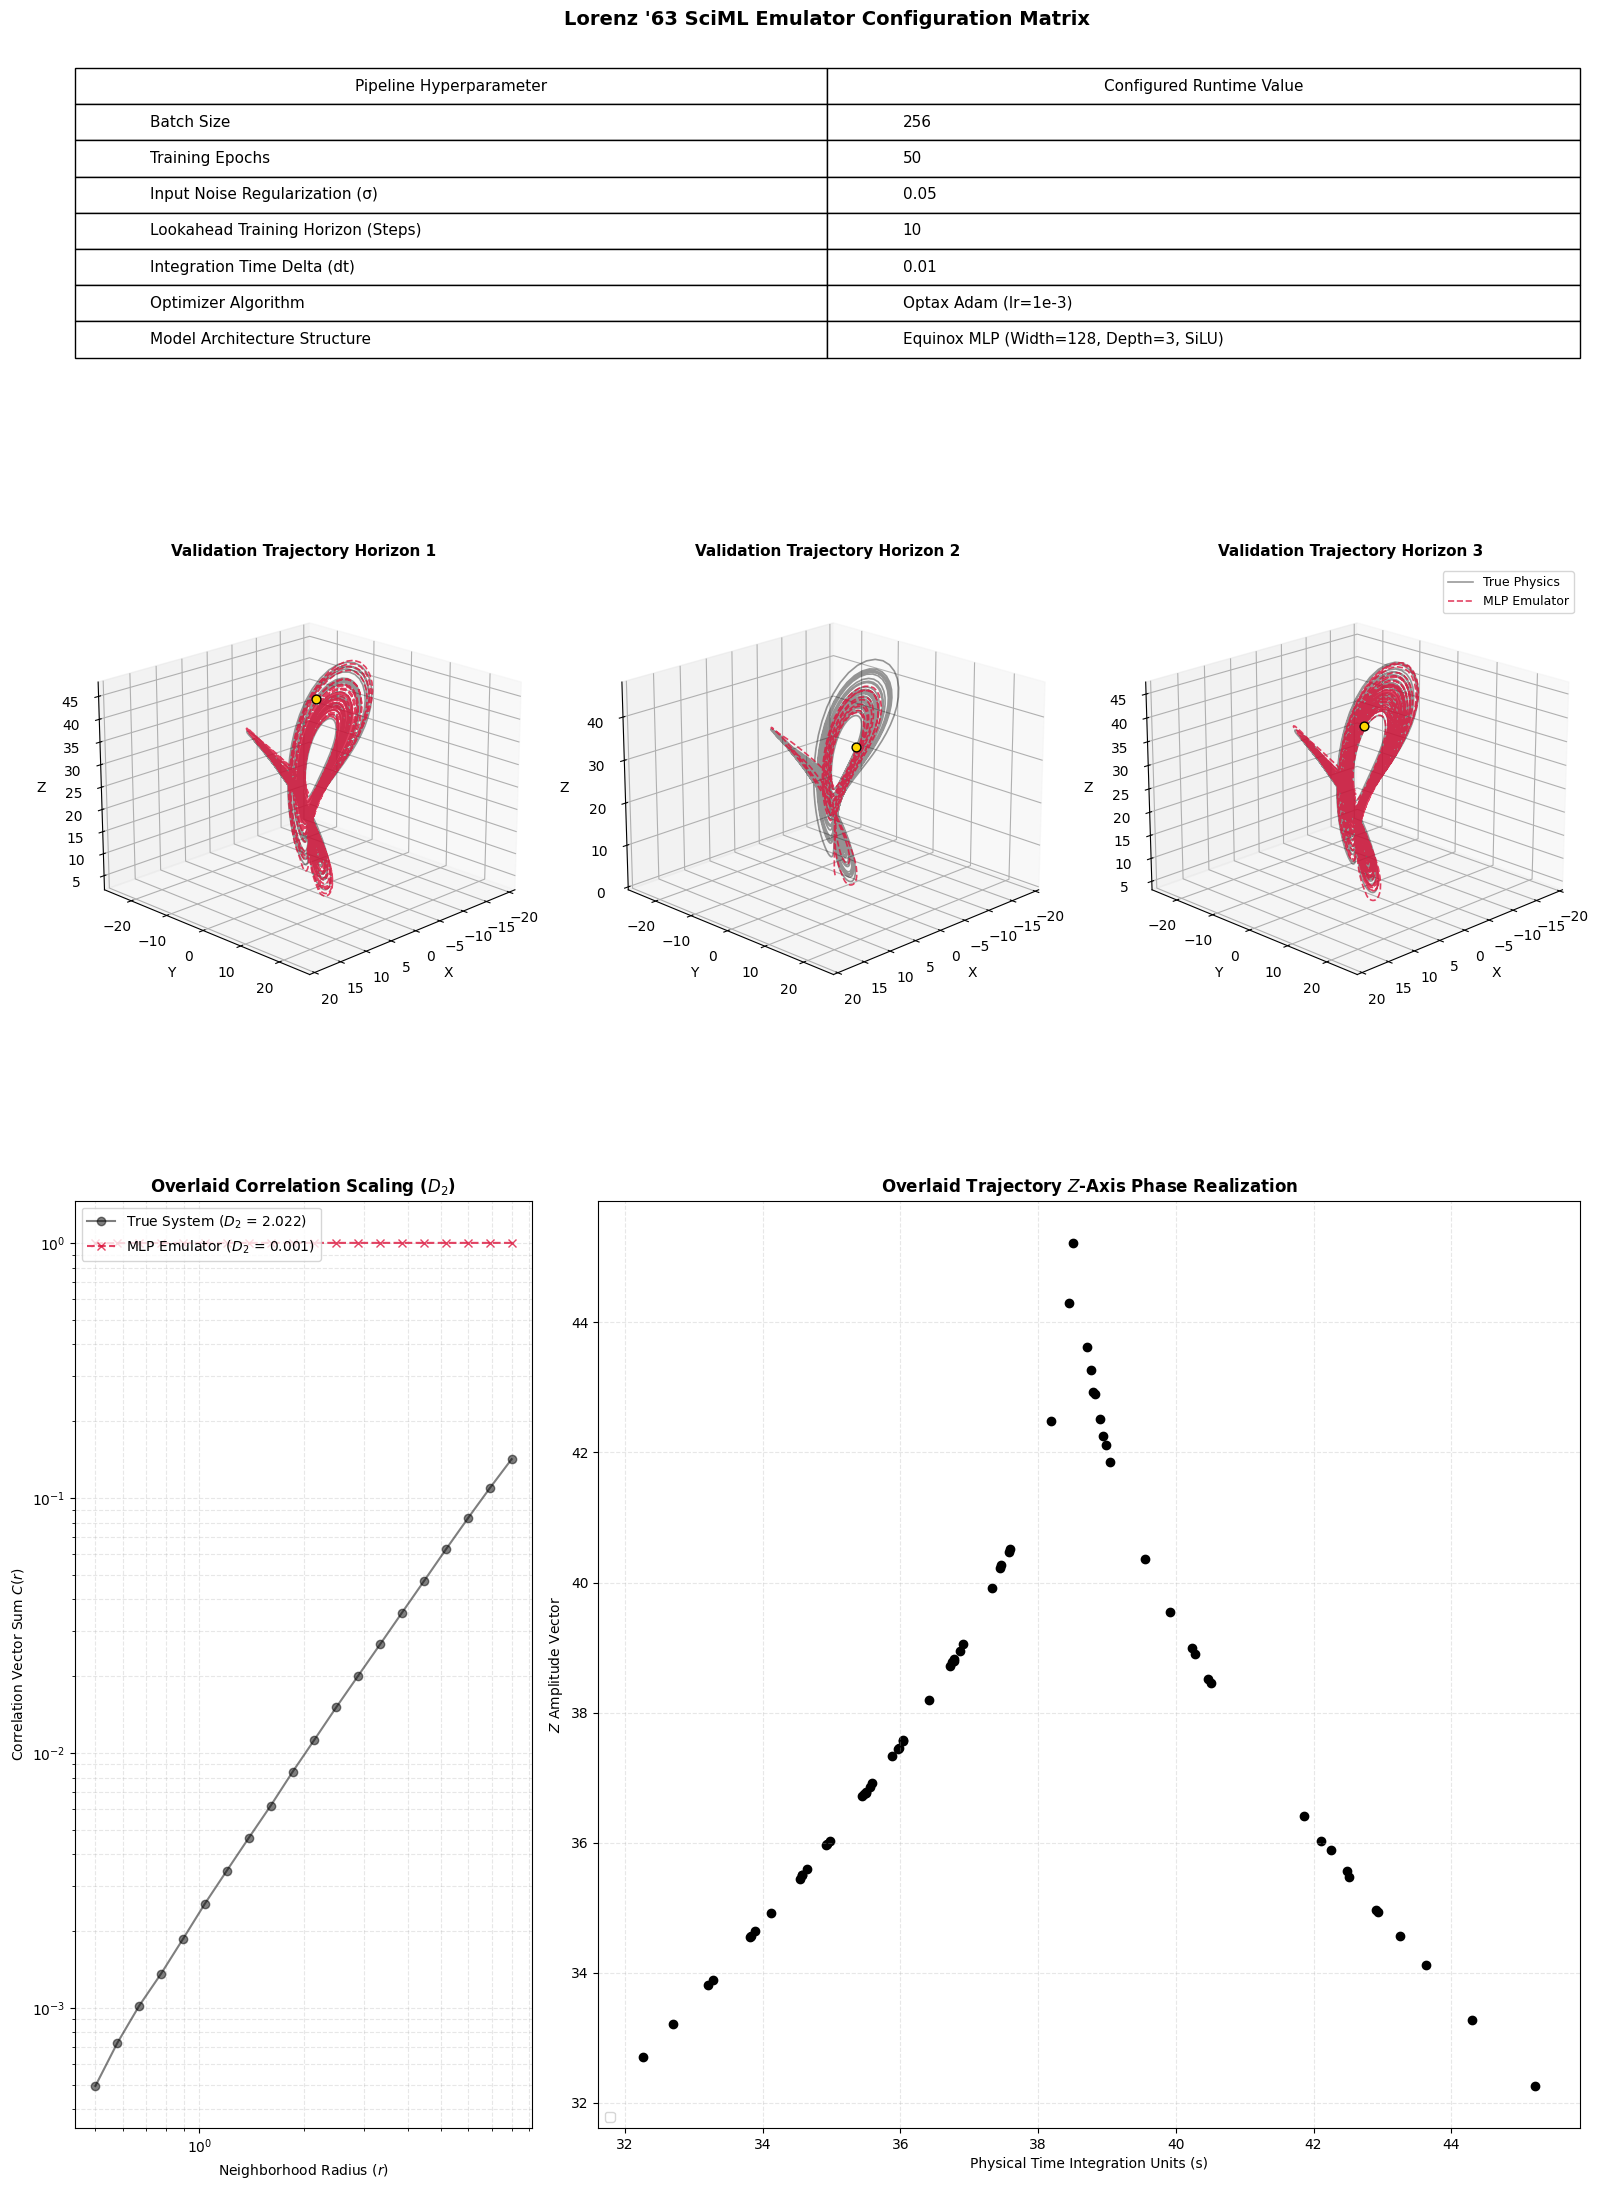

In [52]:
pipeline_configs = {
    "Batch Size": batch_size,
    "Training Epochs": epochs,
    "Input Noise Regularization (\u03C3)": noise_scale,
    "Lookahead Training Horizon (Steps)": PRED_HORIZON,
    "Integration Time Delta (dt)": dt,
    "Optimizer Algorithm": "Optax Adam (lr=1e-3)",
    "Model Architecture Structure": "Equinox MLP (Width=128, Depth=3, SiLU)"
}

eval_slice = historical_traj_1[::2]
d2_gt, radii_gt, C_r_gt = calculate_fractal_dimension(eval_slice, r_min=0.5, r_max=8.0)

emu_traj = prediction_func(model, jnp.array((1.5, 1.5, 1.5)), total_steps)
d2_emu, radii_emu, C_r_emu = calculate_fractal_dimension(emu_traj, r_min=0.5, r_max=8.0)

# 3. Call the unified visual script
save_and_render_unified_dashboard(
    params_dict=pipeline_configs,
    test_init_conditions=testing_initial_states,
    test_trajs=testing_trajs,
    steps_per_traj=total_steps,
    dt=dt,
    radii_gt=radii_gt, C_r_gt=C_r_gt, d2_gt=d2_gt,
    radii_emu=radii_emu, C_r_emu=C_r_emu, d2_emu=d2_emu,
    true_path_long=historical_traj_1,
    emu_path_long=emu_traj,
    filename=f"lorenz_experiment_dashboard_noise:{noise_scale}_dt:{dt}_.png"
)

In [26]:
emu_traj = prediction_func(model, jnp.array((1.5, 1.5, 1.5)), total_steps)

d2_score, radii, C_r = calculate_fractal_dimension(emu_traj, r_min=0.5, r_max=8.0)

print(f"Emulated Attractor Fractal Dimension (D2): {d2_score:.4f}")

Emulated Attractor Fractal Dimension (D2): 0.1480


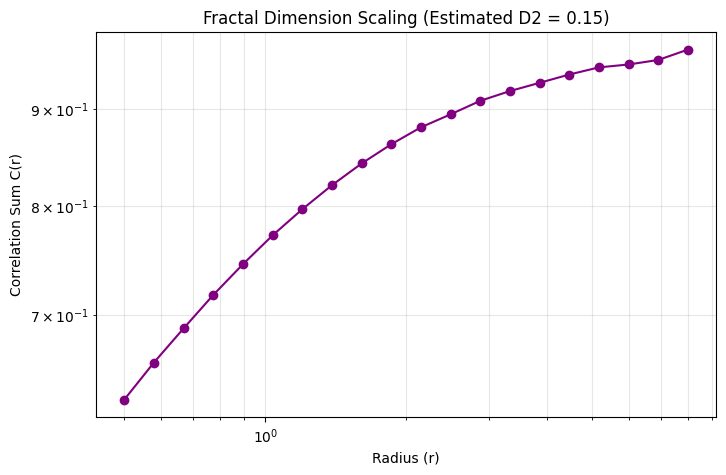

In [27]:
plt.figure(figsize=(8, 5))
plt.loglog(radii, C_r, '-o', color='purple', label='Data Correlation Curve')
plt.title(f"Fractal Dimension Scaling (Estimated D2 = {d2_score:.2f})")
plt.xlabel("Radius (r)")
plt.ylabel("Correlation Sum C(r)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

In [29]:
eval_slice = historical_traj_1[::2]

d2_score, radii, C_r = calculate_fractal_dimension(eval_slice, r_min=0.5, r_max=8.0)

print(f"Emulated Attractor Fractal Dimension (D2): {d2_score:.4f}")

Emulated Attractor Fractal Dimension (D2): 2.0218


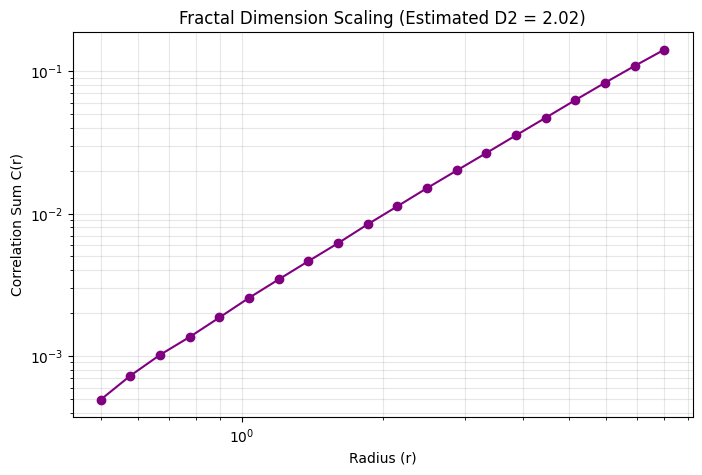

In [30]:
plt.figure(figsize=(8, 5))
plt.loglog(radii, C_r, '-o', color='purple', label='Data Correlation Curve')
plt.title(f"Fractal Dimension Scaling (Estimated D2 = {d2_score:.2f})")
plt.xlabel("Radius (r)")
plt.ylabel("Correlation Sum C(r)")
plt.grid(True, which="both", alpha=0.3)
plt.show()

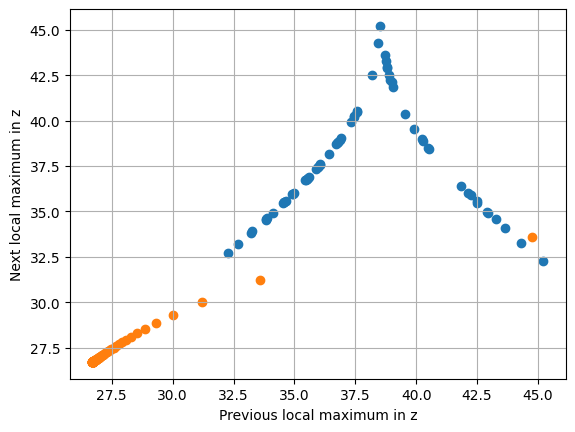

In [33]:
# longer trajectories
maximal_values_gt = find_maxima_in_z(historical_traj_1[burn_in_steps:])
maximal_values_emu = find_maxima_in_z(emu_traj)
plt.scatter(maximal_values_gt[:-1], maximal_values_gt[1:])
plt.scatter(maximal_values_emu[:-1], maximal_values_emu[1:])
plt.xlabel("Previous local maximum in z")
plt.ylabel("Next local maximum in z")
plt.grid()

In [ ]:
import matplotlib.pyplot as plt
import jax.numpy as jnp
from pathlib import Path

def save_and_render_analysis_plots(radii, C_r, d2_score, true_path, emu_path, dt, filename="geometry_analysis.png", folder="plots"):
    """
    Generates and saves the analysis plots for:
    1. Fractal Dimension scaling curve (Log-Log)
    2. Maximum Z-value tracking over a rolling window / time series
    """
    # Ensure plots folder exists
    dir_path = Path(folder)
    dir_path.mkdir(parents=True, exist_ok=True)

    # Setup side-by-side subplots (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # ----------------------------------------------------
    # SUBPLOT 1: Fractal Dimension Log-Log Curve
    # ----------------------------------------------------
    ax1.loglog(radii, C_r, '-o', color='purple', lw=1.5, label='Correlation Data')

    # Title showing the calculated slope metric
    ax1.set_title(f"Fractal Dimension Scaling (Estimated $D_2$ = {d2_score:.3f})", fontsize=12)
    ax1.set_xlabel("Radius ($r$)", fontsize=10)
    ax1.set_ylabel("Correlation Sum $C(r)$", fontsize=10)
    ax1.grid(True, which="both", alpha=0.3, ls="--")
    ax1.legend(loc="upper left")

    # ----------------------------------------------------
    # SUBPLOT 2: Maximum Z-Value Tracking over Time
    # ----------------------------------------------------
    time_axis = jnp.arange(len(true_path)) * dt

    # Extract Z coordinates
    true_z = true_path[:, 2]
    emu_z = emu_path[:, 2]

    # Plot the full raw Z profiles
    ax2.plot(time_axis, true_z, color='black', alpha=0.4, label='True Physics $Z$')
    ax2.plot(time_axis, emu_z, color='crimson', alpha=0.8, linestyle='--', label='Emulator $Z$')

    # Highlight the absolute maximum peaks found by both models
    max_true_z = jnp.max(true_z)
    max_emu_z = jnp.max(emu_z)

    ax2.axhline(max_true_z, color='black', alpha=0.6, linestyle=':', label=f'True Max $Z$ ({max_true_z:.2f})')
    ax2.axhline(max_emu_z, color='crimson', alpha=0.6, linestyle=':', label=f'Emu Max $Z$ ({max_emu_z:.2f})')

    ax2.set_title("Trajectory $Z$-Axis Profile & Bound Verification", fontsize=12)
    ax2.set_xlabel("Physical Time (seconds)", fontsize=10)
    ax2.set_ylabel("$Z$ Coordinate Magnitude", fontsize=10)
    ax2.grid(True, alpha=0.3, ls="--")
    ax2.legend(loc="lower left", fontsize=9)

    # Adjust alignment layout
    plt.tight_layout()

    # Save directly to file before display blocks execution
    output_path = dir_path / filename
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f" Successfully exported geometric analysis plot to: {output_path}")

    plt.show()
    plt.close(fig)  # Free background memory

In [ ]:
import jax.numpy as jnp

def compute_trajectory_psd(trajectory_coordinate, dt):
    """
    Computes the Power Spectral Density of a single coordinate timeline.

    trajectory_coordinate: JAX array of shape (time_steps,) e.g., trajectory[:, 0]
    dt: float, the simulation time step
    """
    N = len(trajectory_coordinate)

    # 1. Remove the mean (DC offset) to focus purely on the oscillations
    signal = trajectory_coordinate - jnp.mean(trajectory_coordinate)

    # 2. Compute the Real Fast Fourier Transform (rfft is optimized for real-valued signals)
    fft_vals = jnp.fft.rfft(signal)

    # 3. Calculate the Power (Magnitude Squared, normalized by sample size)
    psd_vals = (jnp.abs(fft_vals) ** 2) / N

    # 4. Generate the corresponding physical frequency axes (cycles per time unit)
    frequencies = jnp.fft.rfftfreq(N, d=dt)

    return frequencies, psd_vals

In [ ]:
# 1. Generate a long continuous evaluation timeline (e.g., 20,000 steps)
eval_steps = 20000
time_units = eval_steps * dt
eval_start = testing_initial_states[0]

# Generate true physics trajectory using Diff

# 2. Extract the X-coordinate timelines
true_x = historical_traj_1[:, 0]
emu_x = emu_traj[:, 0]

# 3. Compute PSDs
frequencies_true, psd_true = compute_trajectory_psd(true_x, dt)
frequencies_emu, psd_emu = compute_trajectory_psd(emu_x, dt)

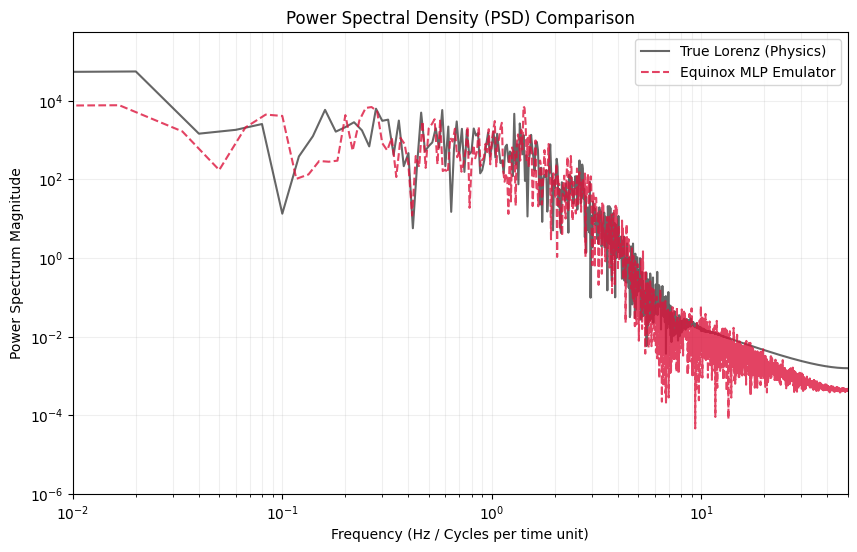

In [ ]:
plt.figure(figsize=(10, 6))

# Plot True Physics PSD
plt.loglog(frequencies_true, psd_true, color='black', alpha=0.6, label='True Lorenz (Physics)')

# Plot Emulator PSD
plt.loglog(frequencies_emu, psd_emu, color='crimson', alpha=0.8, linestyle='--', label='Equinox MLP Emulator')

# Statistical limits for clean visualization
plt.xlim(1e-2, 1 / (2 * dt))  # Limit up to the Nyquist frequency
plt.ylim(1e-6, jnp.max(psd_true) * 10)

plt.title("Power Spectral Density (PSD) Comparison")
plt.xlabel("Frequency (Hz / Cycles per time unit)")
plt.ylabel("Power Spectrum Magnitude")
plt.grid(True, which="both", ls="-", alpha=0.2)
plt.legend()
plt.show()

In [ ]:
# lyaponove exponent stepper
def lyaponove_model_stepper(carry, _):
    state_A, state_B = carry

    next_state_A = model(state_A)
    next_state_B = model(state_B)

    current_distance = jnp.linalg.norm(next_state_B - next_state_A) + 1e-15

    growth_factor = current_distance / delta

    direction_vector = (next_state_B - next_state_A) / current_distance
    adjusted_state_B = next_state_A + (direction_vector * delta)

    next_carry = (next_state_A, adjusted_state_B)

    return next_carry, (next_state_A, growth_factor)

In [ ]:
# lyapanove expon
## initial conditions
lyap_steps = 1000000
direction = jnp.array([1.0, 0.0, 0.0])
displacement = direction * delta
state_A_init = jnp.array([1.0, 1.0, 1.0])
state_B_init = state_A_init + displacement
initial_carry = (state_A_init, state_B_init)

_ , historical_growth = jax.lax.scan(lyaponove_model_stepper, initial_carry, jnp.arange(lyap_steps))

log_growths = jnp.log(historical_growth[1])
total_log_growth = jnp.sum(log_growths)
total_time = lyap_steps * dt

lyapunov_exponent = total_log_growth / total_time
print(lyapunov_exponent)

-11.855647137359007


In [ ]:
short_real_traj_A = prediction_func(model, state_A_init, 10)
short_real_traj_B = prediction_func(model, state_B_init, 10)

In [ ]:
# plot
fig = plt.figure(figsize=(10, 6), projection = "3d")

fig.plot()

SyntaxError: invalid syntax (1346071017.py, line 3)

In [ ]:
import jax
import jax.numpy as jnp

delta = 1e-4  # Perturbation scale

def gram_schmidt_3d(V, delta):
    """
    Takes a (3, 3) matrix V of deformed perturbation vectors.
    Orthogonalizes them and returns the normalized vectors and their growth factors.
    """
    v1, v2, v3 = V[0], V[1], V[2]

    # Axis 1: The dominant stretching direction (Maximal)
    norm1 = jnp.linalg.norm(v1) + 1e-15
    u1 = v1 / norm1
    g1 = norm1 / delta

    # Axis 2: Strip out any projection along u1 (Neutral/Flow direction)
    v2_orthogonal = v2 - jnp.dot(v2, u1) * u1
    norm2 = jnp.linalg.norm(v2_orthogonal) + 1e-15
    u2 = v2_orthogonal / norm2
    g2 = norm2 / delta

    # Axis 3: Strip out projections along both u1 and u2 (Compression direction)
    v3_orthogonal = v3 - jnp.dot(v3, u1) * u1 - jnp.dot(v3, u2) * u2
    norm3 = jnp.linalg.norm(v3_orthogonal) + 1e-15
    u3 = v3_orthogonal / norm3
    g3 = norm3 / delta

    # Re-assemble the pristine, re-orthogonalized tracking frame
    orthogonal_frame = jnp.stack([u1 * delta, u2 * delta, u3 * delta])
    growth_factors = jnp.array([g1, g2, g3])

    return orthogonal_frame, growth_factors

def full_spectrum_stepper(carry, _):
    state_A, perturbation_matrix = carry

    # Step 1: Evolve the primary baseline state
    next_state_A = model(state_A)

    # Step 2: Generate the 3 current perturbed states
    perturbed_states = state_A + perturbation_matrix

    # Step 3: Evaluate all 3 through the Equinox model at once using vmap
    next_perturbed_states = jax.vmap(model)(perturbed_states)

    # Step 4: Extract the raw deformed deviations
    raw_deviations = next_perturbed_states - next_state_A

    # Step 5: Orthonormalize the frame and harvest the growth metrics
    adjusted_perturbations, growth_factors = gram_schmidt_3d(raw_deviations, delta)

    next_carry = (next_state_A, adjusted_perturbations)
    return next_carry, growth_factors

In [ ]:
# Initialize using the first clean testing state
eval_start = testing_initial_states[0]
init_perturbations = jnp.eye(3) * delta

initial_spectrum_carry = (eval_start, init_perturbations)
spec_steps = 15000

# Run the compiled simulation loop
_, spectrum_growth_history = jax.lax.scan(
    full_spectrum_stepper, initial_spectrum_carry, None, length=spec_steps
)

# Warm-up phase: Drop the first 10% of steps so the vectors can align properly
warmup = int(spec_steps * 0.1)
clean_growth_history = spectrum_growth_history[warmup:]

# Calculate the final time-averaged exponents: λ = <ln(g)> / dt
log_growths = jnp.log(clean_growth_history + 1e-15)
average_log_growths = jnp.mean(log_growths, axis=0)
lyapunov_spectrum = average_log_growths / dt

print("=== Trained MLP Lyapunov Spectrum ===")
print(f"λ1 (Stretching Axis):     {lyapunov_spectrum[0]:.4f}")
print(f"λ2 (Flow/Neutral Axis):   {lyapunov_spectrum[1]:.4f}")
print(f"λ3 (Compression Axis):    {lyapunov_spectrum[2]:.4f}")

=== Trained MLP Lyapunov Spectrum ===
λ1 (Stretching Axis):     -0.0001
λ2 (Flow/Neutral Axis):   -0.0001
λ3 (Compression Axis):    -0.0002


In [ ]:
# vtp - valid time prediction
def calc_vtp(true_traj, pred_traj, delta_t, threshold=0.3):
    true_mean = jnp.mean(true_traj, axis=0)
    attractor_variance = jnp.mean(jnp.sum((true_traj - true_mean) ** 2, axis=-1))
    attractor_scale = jnp.sqrt(attractor_variance)

    step_error = jnp.linalg.norm(true_traj - true_traj, axis=-1)
    nrmse_timeline = step_error / attractor_scale

    exceeded_threshold = nrmse_timeline > threshold
    first_failure_idx = jnp.argmax(exceeded_threshold)

    has_failed = jnp.any(exceeded_threshold)
    vtp_steps = jnp.where(has_failed, first_failure_idx, len(true_traj))

    vtp_time = vtp_steps * delta_t

    return vtp_time, nrmse_timeline

In [ ]:
# finding vtp
eval_steps = 2000
save_ts = jnp.arange(0.0, eval_steps * dt, dt)
physics_sol = diffeqsolve(term, solver, t0=0, t1=eval_steps*dt, dt0=dt, y0=eval_start, args=parms, saveat=SaveAt(ts=save_ts))
true_path = physics_sol.ys
emu_path = prediction_func(model, eval_start, eval_steps)
vtp_score, error_timeline = calc_vtp(true_path, emu_path, dt)
print(f"vtp: {vtp_score:.4f} time units")
print(f"steps accurately tracked: {int(vtp_score / dt)}")

vtp: 20.0000 time units
steps accurately tracked: 2000


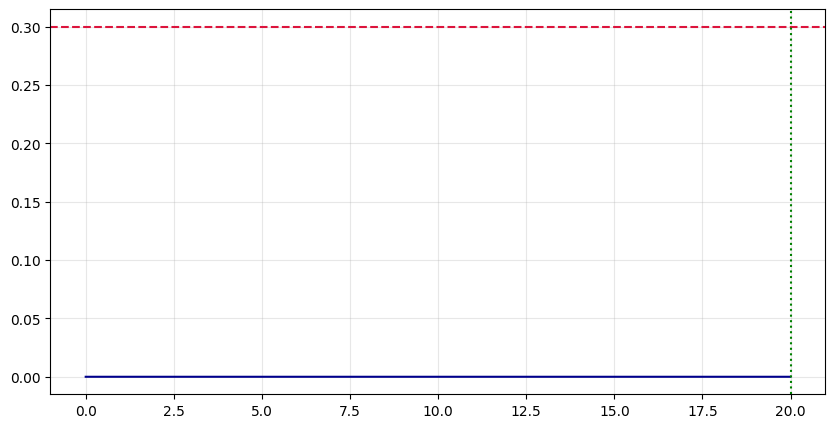

In [ ]:
# vtp graph
plt.figure(figsize=(10, 5))
time_axis = jnp.arange(eval_steps) * dt

plt.plot(time_axis, error_timeline, color='darkblue', label='Emulator NRMSE')
plt.axhline(y=0.3, color='crimson', linestyle='--', label='VTP Failure Threshold (0.3)')
plt.axvline(x=vtp_score, color='green', linestyle=':', label=f'VTP Horizon ({vtp_score:.2f})')
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# implementing gram_schimit to help with finding the full lyapunove specturm
def gram_schmidt_3d(V, delta):
    v1, v2, v3 = V[0], V[1], V[2]

    norm1 = jnp.linalg.norm(v1) + 1e-15
    u1 = v1 / norm1
    g1 = norm1 / delta

    v2_proj = v2 - jnp.dot(v2, u1) * u1
    norm2 = jnp.linalg.norm(v2_proj) + 1e-15
    u2 = v2_proj / norm2
    g2 = norm2 / delta

    v3_proj = v3 - jnp.dot(v3, u1) * u1 - jnp.dot(v3, u2) * u2
    norm3 = jnp.linalg.norm(v3_proj) + 1e-15
    u3 = v3_proj / norm3
    g3 = norm3 / delta

    orthogonal_vectors = jnp.stack([u1 * delta, u2 * delta, u3 * delta])
    growth_factors = jnp.array([g1, g2, g3])

    return orthogonal_vectors, growth_factors

In [ ]:
# stepper for the lyapunove spectrum
def spectrum_stepper(carry, _):
    state_A, perturbation_matrix = carry

    next_state_A = model(state_A)

    perturbed_states = state_A + perturbation_matrix

    next_perturbed_states = jax.vmap(model)(perturbed_states)

    raw_deviations = next_perturbed_states - next_state_A

    adjusted_perturbations, growth_factors = gram_schmidt_3d(raw_deviations, delta)

    next_carry = (next_state_A, adjusted_perturbations)

    return next_carry, growth_factors

In [ ]:
# finding the lyapunove specturm
delta = 1e-4
init_perturbations = jnp.eye(3) * delta
eval_start = jnp.array([1.0, 1.0, 1.0])

initial_spectrum_carry = (eval_start, init_perturbations)
spec_steps = 10000

_, spectrum_growth_history = jax.lax.scan(
    spectrum_stepper, initial_spectrum_carry, None, length=spec_steps
)

warmup = int(spec_steps * 0.1)
clean_spectrum_growth = spectrum_growth_history[warmup:]

log_spectrum_growths = jnp.log(clean_spectrum_growth + 1e-15)
average_log_growths = jnp.mean(log_spectrum_growths, axis=0)

lyapunov_spectrum = average_log_growths / dt

print("--- Calculated Lyapunov Spectrum ---")
print(f"λ1 (Maximal - Stretching):  {lyapunov_spectrum[0]:.4f}")
print(f"λ2 (Neutral - Attractor):   {lyapunov_spectrum[1]:.4f}")
print(f"λ3 (Minimal - Compression): {lyapunov_spectrum[2]:.4f}")

--- Calculated Lyapunov Spectrum ---
λ1 (Maximal - Stretching):  -27.5460
λ2 (Neutral - Attractor):   -87.2478
λ3 (Minimal - Compression): -129.2530


In [ ]:
import jax
import jax.numpy as jnp

# True Lorenz '63 parameters
SIGMA = 10.0
RHO = 28.0
BETA = 8.333333333333334 / 3.0  # 8/3

def lorenz_deriv(state):
    """The standard physical Lorenz equations."""
    x, y, z = state[0], state[1], state[2]
    dxdt = SIGMA * (y - x)
    dydt = x * (RHO - z) - y
    dzdt = x * y - BETA * z
    return jnp.array([dxdt, dydt, dzdt])

# Use JAX automatic differentiation to get the exact Jacobian function
lorenz_jacobian = jax.jacobian(lorenz_deriv)

def physical_spectrum_stepper(carry, _):
    state, Q_matrix = carry  # Q_matrix is our orthogonal frame matrix of shape (3, 3)

    # 1. Evaluate the true physics derivative at the current state
    f_val = lorenz_deriv(state)

    # 2. Evaluate the exact structural Jacobian at this point
    Df = lorenz_jacobian(state)

    # 3. Advance the primary trajectory by 1 physical step (Euler integration)
    next_state = state + f_val * dt

    # 4. Linearly evolve our tracking frame using the Jacobian matrix
    #    dQ/dt = Df @ Q
    next_Q_raw = Q_matrix + jnp.matmul(Df, Q_matrix) * dt

    # 5. Run Gram-Schmidt to decouple the axes and pull out growth factors
    next_Q_orthogonal, growth_factors = gram_schmidt_3d(next_Q_raw, delta=1.0)

    next_carry = (next_state, next_Q_orthogonal)
    return next_carry, growth_factors

In [ ]:
# Setup initial parameters
dt = 0.001  # A smaller dt ensures high accuracy for physical integration
physical_steps = 50000

# Start from one of your stable test coordinates
physical_start_state = testing_initial_states[0]

# Initialize our perturbation tracking frame as a perfect Identity Matrix (perpendicular unit axes)
init_frame = jnp.eye(3)

initial_physical_carry = (physical_start_state, init_frame)

print("Integrating Physical Variational Equations...")

# Run the compiled JAX scan loop
_, physical_growth_history = jax.lax.scan(
    physical_spectrum_stepper, initial_physical_carry, None, length=physical_steps
)

# Burn-in: Trim away the first 10% of steps so vectors align flawlessly with the true directions
warmup = int(physical_steps * 0.1)
stable_physical_growth = physical_growth_history[warmup:]

# Calculate the true physical Lyapunov spectrum: λ = <ln(g)> / dt
log_physical_growths = jnp.log(stable_physical_growth + 1e-15)
average_phys_log_growths = jnp.mean(log_physical_growths, axis=0)
true_lyapunov_spectrum = average_phys_log_growths / dt

print("\n=== True Physical Model Lyapunov Spectrum ===")
print(f"λ1 (True Stretching):   {true_lyapunov_spectrum[0]:.4f}")
print(f"λ2 (True Flow Axis):    {true_lyapunov_spectrum[1]:.4f}")
print(f"λ3 (True Compression):  {true_lyapunov_spectrum[2]:.4f}")

Integrating Physical Variational Equations...

=== True Physical Model Lyapunov Spectrum ===
λ1 (True Stretching):   -9.9993
λ2 (True Flow Axis):    -1.0642
λ3 (True Compression):  -2.7496
